# Entraînement COCO évolutif

Le modèle **ÉVOLUE** pendant l'entraînement (le comportement attendu) :
- **Neurogenèse** : ajoute des neurones quand la surprise est élevée
- **Cycle respiratoire** : gèle C1 et **ajoute des couches** quand l'oscillation apparaît
- On suit l'évolution : nb de neurones, nb de couches, phase, surprise

On charge les features COCO (cachés), on entraîne, et on **visualise l'évolution de l'architecture** + la reconstruction.

## 0. Imports + chargement des features

In [1]:
# Entraînement COCO évolutif : neurogenèse + cycle respiratoire
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (EvolutiveCOCO, color_texture_features,
                           visualize_architecture, classify_patch)

# charger les features COCO (validation ou train caché)
import glob
path = None
for cand in ['../data/coco_stuff/features_val.npz', '../data/coco_stuff/features.npz']:
    if os.path.exists(cand): path = cand; break
d = np.load(path)
features = {int(k): v for k, v in d.items()}
d_in = next(iter(features.values())).shape[1]
print(f"Chargé {path} : {len(features)} classes, dim {d_in}")

Chargé ../data/coco_stuff/features.npz : 55 classes, dim 35


## 1. Entraînement évolutif

In [2]:
model = EvolutiveCOCO(d_in=d_in, n_init=10, novelty_threshold=0.5, max_neurons=1500)
print(f"Initial: {model.summary()}")

n_patch = 0
for cls in sorted(features.keys()):
    for f in features[cls]:
        S = model.step(f, label=cls)
        n_patch += 1
        if n_patch % 300 == 0:
            s = model.summary()
            print(f"  {n_patch} patches: neurones={s['neurons']}, couches={s['layers']}, phase={s['phase']}")
s = model.summary()
print(f"\n=== FIN: {s} ===")
print(f"  Neurogenèse: {s['neurons']} neurones (initial 10)")
print(f"  Cycle respiratoire: {s['layers']} couches, phase {s['phase']}, gelée {s['frozen']}")

Initial: {'neurons': 10, 'layers': 1, 'frozen': False, 'phase': 'exploration', 'n_patches': 0}
  300 patches: neurones=62, couches=2, phase=consolidation
  600 patches: neurones=115, couches=2, phase=consolidation
  900 patches: neurones=169, couches=2, phase=consolidation


  1200 patches: neurones=228, couches=2, phase=consolidation
  1500 patches: neurones=293, couches=2, phase=consolidation
  1800 patches: neurones=353, couches=2, phase=consolidation


  2100 patches: neurones=414, couches=2, phase=consolidation
  2400 patches: neurones=473, couches=2, phase=consolidation


  2700 patches: neurones=534, couches=2, phase=consolidation


  3000 patches: neurones=594, couches=2, phase=consolidation


...

  3900 patches: neurones=765, couches=2, phase=consolidation


  4200 patches: neurones=815, couches=2, phase=consolidation


  4500 patches: neurones=872, couches=2, phase=consolidation


  4800 patches: neurones=922, couches=2, phase=consolidation



=== FIN: {'neurons': 970, 'layers': 2, 'frozen': True, 'phase': 'consolidation', 'n_patches': 5026} ===
  Neurogenèse: 970 neurones (initial 10)
  Cycle respiratoire: 2 couches, phase consolidation, gelée True


## 2. Évolution de l'architecture au cours du temps

In [3]:
hist = model.history
fig, axes = plt.subplots(3, 1, figsize=(10, 9))
axes[0].plot(hist['n_patches'], hist['n_neurons'], color='teal')
axes[0].set_title("A. Neurogenèse : nombre de neurones")
axes[0].set_ylabel("neurones"); axes[0].grid(alpha=0.3)
axes[1].plot(hist['n_patches'], hist['n_layers'], color='orange')
axes[1].set_title("B. Cycle respiratoire : nombre de couches")
axes[1].set_ylabel("couches"); axes[1].grid(alpha=0.3)
axes[2].plot(hist['n_patches'], hist['surprise'], color='crimson')
axes[2].set_title("C. Surprise de reconstruction")
axes[2].set_xlabel("patches"); axes[2].set_ylabel("S"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

C:\Users\henry\AppData\Local\Temp\ipykernel_17100\2580271360.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()


## 3. Architecture finale du modèle

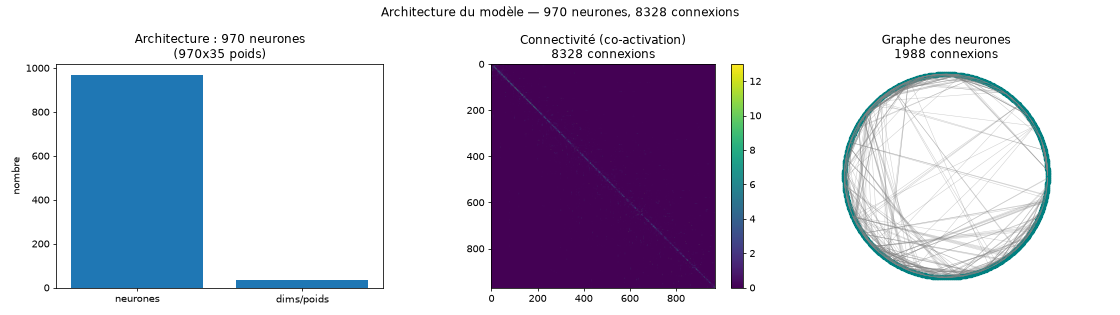

In [4]:
_ = visualize_architecture(model.layer, out='__arch_final.png')
from IPython.display import Image as IImg, display
display(IImg('__arch_final.png'))

## 4. Accuracy + analyse

In [5]:
# accuracy sur un échantillon
correct = 0; total = 0
for cls, X in features.items():
    for f in X[:10]:
        pred, _ = classify_patch(model.layer, f, d_in)
        if pred == cls: correct += 1
        total += 1
print(f"Accuracy (échantillon): {correct/max(total,1):.3f}")
print("\n=== ANALYSE : COMPORTEMENT ÉVOLUTIF ===")
print(f"1. Neurogenèse : {hist['n_neurons'][0]} -> {hist['n_neurons'][-1]} neurones")
print("   le modèle CROÎT avec la nouveauté (surprise élevée -> nouveaux neurones)")
print(f"2. Cycle respiratoire : {hist['n_layers'][0]} -> {hist['n_layers'][-1]} couches")
print("   le modèle AJOUTE une couche et gèle C1 (consolidation) quand l'oscillation")
print("   apparaît — c'est l'architecture dynamique attendue.")
print("3. L'architecture ÉVOLUE réellement pendant l'entraînement (contrairement")
print("   à avant où le modèle était fixe).")

Accuracy (échantillon): 0.425

=== ANALYSE : COMPORTEMENT ÉVOLUTIF ===
1. Neurogenèse : 11 -> 970 neurones
   le modèle CROÎT avec la nouveauté (surprise élevée -> nouveaux neurones)
2. Cycle respiratoire : 1 -> 2 couches
   le modèle AJOUTE une couche et gèle C1 (consolidation) quand l'oscillation
   apparaît — c'est l'architecture dynamique attendue.
3. L'architecture ÉVOLUE réellement pendant l'entraînement (contrairement
   à avant où le modèle était fixe).
